In [8]:
import pandas as pd
import seaborn as sns
import numpy as np
from statsmodels.formula.api import logit
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pylab import rcParams
from statsmodels.graphics.mosaicplot import mosaic

In [9]:
#Uncleaned Data
data = pd.read_csv('D:\DataProjects\WGU\Data Cleaning PA\churn\churn_raw_data.csv', index_col = 0)

#Explanatory Variables Selected for cleaning
cols_keep = ['Churn','Outage_sec_perweek','Contacts','Multiple',
             'InternetService', 'OnlineBackup','OnlineSecurity',
             'Contract','StreamingTV','StreamingMovies','Income',
             'Tenure','MonthlyCharge','DeviceProtection',
             'item1','item2','item3','item4','item5','item6','item7','item8']

# Prints number of missing values in columns if column has missing values
print(data.loc[data.isnull().values,['Tenure','Bandwidth_GB_Year','Income']].isnull().sum())
# Prints size of dataset if we remove nulls and a column
data = data.drop([x for x in data.columns if x not in cols_keep],axis = 1).dropna().reset_index(drop=True)
print(f'Bandwidth Dropped due to high correlation with Tenure and larger number of missing values, Size of dataset:{len(data)}')

Tenure               2170
Bandwidth_GB_Year    2340
Income               5352
dtype: int64
Bandwidth Dropped due to high correlation with Tenure and larger number of missing values, Size of dataset:6831


# <font color='green'> Removing Outliers </font>

In [10]:
# Assessing outliers
# Finds Numeric Explanatory Columns 
cols_numeric = [x for x in data.columns if (data[x].dtype != 'object') & (x != 'Churn')]
# Iterates through numeric columns calculating z scores
# Tracking outlier indexes in ind
for i in cols_numeric:
    z = list(stats.zscore(data.loc[:,i]))
    ind = []
    for zscore in z:
        if (zscore >= 3) | (zscore <= -3) & (z.index(zscore) not in ind):
            ind.append(z.index(zscore))
    if len(ind) > 0:
        drop = np.unique(ind)
        data = data.drop(index = drop,axis = 0).reset_index(drop = 'True')
#Removing negative values from outage_sec_perweek
for lab,row in data.iterrows():
    if data.loc[lab,'Outage_sec_perweek'] < 0:
        data.loc[lab,'Outage_sec_perweek'] = 0

print(data.columns)
print(data['InternetService'].value_counts())

Index(['Income', 'Churn', 'Outage_sec_perweek', 'Contacts', 'Contract',
       'InternetService', 'Multiple', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'StreamingTV', 'StreamingMovies', 'Tenure',
       'MonthlyCharge', 'item1', 'item2', 'item3', 'item4', 'item5', 'item6',
       'item7', 'item8'],
      dtype='object')
Fiber Optic    2868
DSL            2170
None           1351
Name: InternetService, dtype: int64


In [11]:
# One Hot Encoding to test Multicollinearity
internet_service = ['Fiber Optic', 'DSL', 'None']
contracts = ['One year', 'Month-to-month', 'Two Year']
# Recursion and List comprehension to iteratively apply one hot encoding
for lab,row in data.iterrows():
    service,contract = data.loc[lab,['InternetService','Contract']]
    # 1 is set for the column indicating the type of contract and type of internet service
    # the customer has
    data.loc[lab,service] = 1
    data.loc[lab,contract] = 1
    zeros =([i for i in contracts if i not in contract],[i for i in internet_service if i not in service])
    # 0 indicates the Internet Service and contract types the customer didn't have
    for col in zeros:
        for val in col:
            data.loc[lab,val] = 0
data = data.drop(columns = ['InternetService','Contract'])
# Ordinal Encoding of Binary Variables
map_cols = ['Churn',
'Multiple', 'OnlineBackup',
'OnlineSecurity', 'StreamingTV',
'StreamingMovies', 'DeviceProtection']
# Iterates through columns mapping 1 to yes values and 0 to no values
for i in map_cols:
    data[i] = data[i].map({'Yes':1,'No':0})

In [12]:
stat = pd.DataFrame()
for i in data.columns:
    index = data[i].describe().index
    for ind in index:
        temp = list(data.columns).index(i)
        stat.loc[temp,'Column'] = i
        stat.loc[temp,ind] = data[i].describe()[ind]
stat

,Column,count,mean,std,min,25%,50%,75%,max
0,Income,6389.0,38342.509305,25253.717153,740.660000,19038.780000,32765.970000,52288.110000,125034.10000
1,Churn,6389.0,0.262013,0.439764,0.000000,0.000000,0.000000,1.000000,1.00000
2,Outage_sec_perweek,6389.0,10.027943,3.215598,0.000000,7.922365,9.986425,12.059022,32.60818
3,Contacts,6389.0,0.986852,0.984769,0.000000,0.000000,1.000000,2.000000,7.00000
4,Multiple,6389.0,0.462357,0.498620,0.000000,0.000000,0.000000,1.000000,1.00000
5,OnlineSecurity,6389.0,0.356707,0.479065,0.000000,0.000000,0.000000,1.000000,1.00000
6,OnlineBackup,6389.0,0.449836,0.497516,0.000000,0.000000,0.000000,1.000000,1.00000
7,DeviceProtection,6389.0,0.436532,0.495994,0.000000,0.000000,0.000000,1.000000,1.00000
8,StreamingTV,6389.0,0.493661,0.499999,0.000000,0.000000,0.000000,1.000000,1.00000
9,StreamingMovies,6389.0,0.487400,0.499880,0.000000,0.000000,0.000000,1.000000,1.00000


In [13]:
data

,Income,Churn,Outage_sec_perweek,Contacts,Multiple,OnlineSecurity,OnlineBackup,DeviceProtection,StreamingTV,StreamingMovies,...,item5,item6,item7,item8,Fiber Optic,One year,Month-to-month,Two Year,DSL,None
0,28561.99,0,6.972566,0,0,1,1,0,0,1,...,4,4,3,4,1.0,1.0,0.0,0.0,0.0,0.0
1,21704.77,1,12.014541,0,1,1,0,0,1,1,...,4,3,4,4,1.0,0.0,1.0,0.0,0.0,0.0
2,18925.23,0,15.206193,2,0,1,0,0,1,0,...,5,4,3,3,0.0,0.0,0.0,1.0,1.0,0.0
3,40074.19,1,8.960316,2,0,0,0,0,1,0,...,4,4,4,5,1.0,0.0,1.0,0.0,0.0,0.0
4,11467.50,1,11.129094,0,0,0,0,0,1,1,...,1,5,5,5,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6384,25432.25,0,12.814690,3,0,0,1,0,0,0,...,4,3,2,2,0.0,0.0,1.0,0.0,0.0,1.0
6385,30724.26,0,11.165050,3,0,1,1,0,1,0,...,5,4,4,2,1.0,1.0,0.0,0.0,0.0,0.0
6386,35876.21,0,9.729936,2,0,0,0,0,1,0,...,4,3,4,3,1.0,0.0,0.0,1.0,0.0,0.0
6387,55723.74,0,9.265392,2,1,0,1,1,0,0,...,4,3,2,3,0.0,0.0,1.0,0.0,1.0,0.0


# <font color='green'> Univariate Distributions </font>

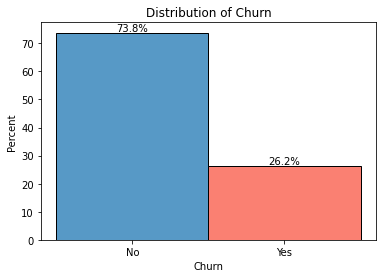

In [14]:
x = sns.histplot(data=data,x = 'Churn', discrete = True,stat='percent')
plt.xticks(ticks = [0,1], labels = ['No','Yes'])
plt.title('Distribution of Churn')
x.bar_label(x.containers[0],labels = [f'{round(x,2)}%' for x in x.containers[0].datavalues])
x.patches[1].set_facecolor('Salmon')
plt.show()

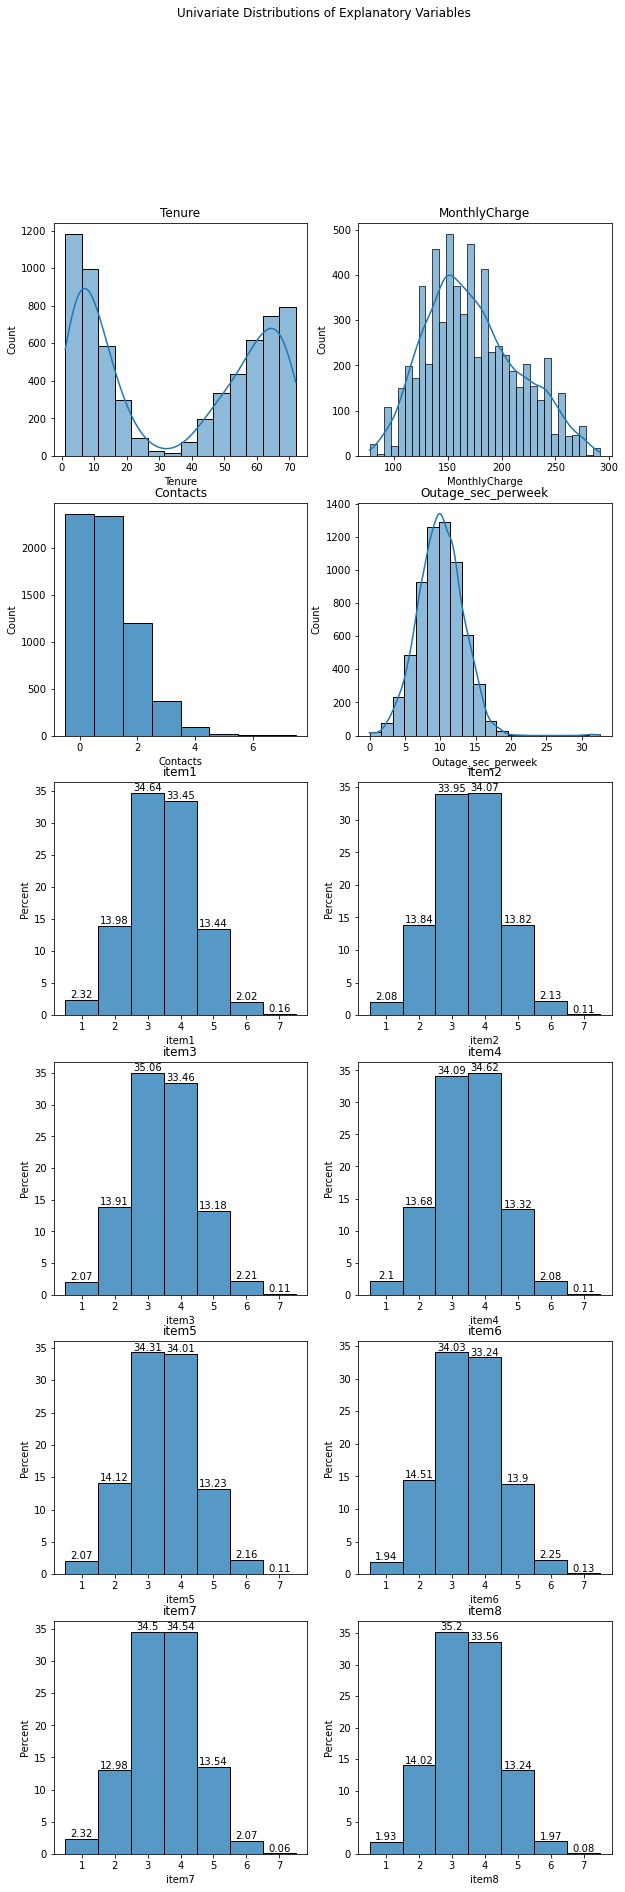

In [15]:
items = [x for x in stat.Column if 'item' in x]
figure, axes = plt.subplots(6, 2, figsize=(10,30))
figure.suptitle('Univariate Distributions of Explanatory Variables')
axes[0][0].set_title('Tenure')
axes[0][1].set_title('MonthlyCharge')
axes[1][0].set_title('Contacts')
axes[1][1].set_title('Outage_sec_perweek')
sns.histplot(ax = axes[0][0],data = data, x = 'Tenure',kde = True)
sns.histplot(ax = axes[0][1],data = data, x = 'MonthlyCharge',kde = True)
sns.histplot(ax = axes[1][0],data = data, x = 'Contacts',discrete = True)
sns.histplot(ax = axes[1][1],data = data, x = 'Outage_sec_perweek',kde = True, bins = 20)
ind1 = 2
ind2 = 0
for i in items:
    axes[ind1][ind2].set_title(f'{i}')
    x = sns.histplot(ax = axes[ind1][ind2], data = data, x = i,discrete= True,stat = 'percent')
    x.bar_label(x.containers[0],labels = [f'{round(x,2)}' for x in x.containers[0].datavalues])
    if ind2 == 0:
        ind2 = 1
    elif ind2 == 1:
        ind1 += 1
        ind2 = 0
plt.show()

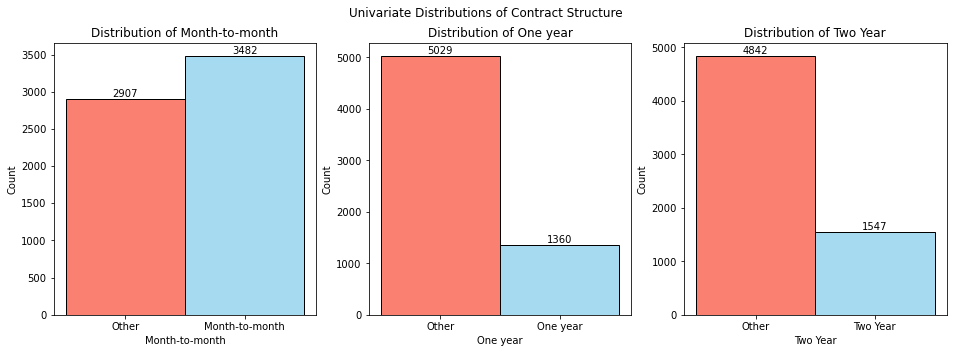

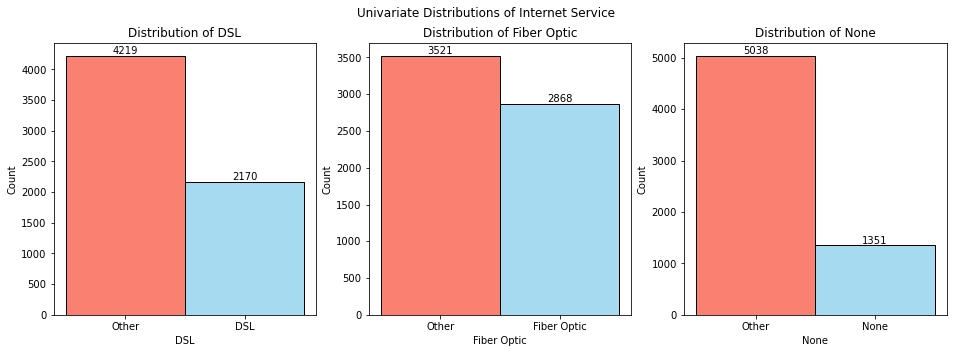

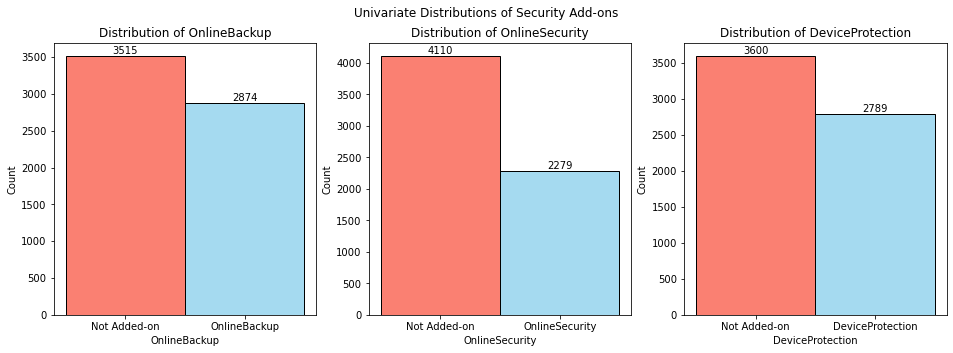

In [16]:
internet_service = ['Internet Service','DSL','Fiber Optic','None']
security = ['Security Add-ons','OnlineBackup','OnlineSecurity','DeviceProtection']
contract = ['Contract Structure','Month-to-month','One year','Two Year']
plots = [contract,internet_service,security]
for i in plots:
    figure, axes = plt.subplots(1, 3, figsize=(16,5))
    figure.suptitle(f'Univariate Distributions of {i[0]}')
    count = 0
    temp_charts = []
    if i[0] != 'Security Add-ons':
        for x in i[1:]:
            axes[count].set_title(f'Distribution of {x}')
            temp_charts.append(sns.histplot(ax = axes[count], data = data,x = f'{x}',stat = 'count',discrete = True,color='skyblue'))
            temp_charts[count].patches[0].set_facecolor('Salmon')
            temp_charts[count].bar_label(temp_charts[count].containers[0])
            axes[count].set_xticks(ticks = [0,1],labels = ['Other',f'{x}'])
            count += 1
    else:
        for x in i[1:]:
            axes[count].set_title(f'Distribution of {x}')
            temp_charts.append(sns.histplot(ax = axes[count], data = data,x = f'{x}',stat = 'count',discrete = True,color='skyblue'))
            temp_charts[count].patches[0].set_facecolor('Salmon')
            temp_charts[count].bar_label(temp_charts[count].containers[0])
            axes[count].set_xticks(ticks = [0,1],labels = ['Not Added-on',f'{x}'])
            count += 1
    plt.show()

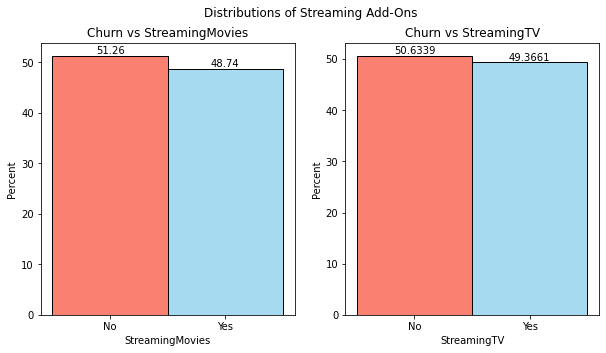

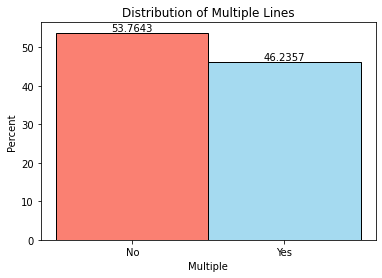

In [17]:
figure, axes = plt.subplots(1, 2, figsize=(10,5))
figure.suptitle('Distributions of Streaming Add-Ons')
axes[0].set_title('Churn vs StreamingMovies')
axes[1].set_title('Churn vs StreamingTV')
a=sns.histplot(ax = axes[0], data = data, x= 'StreamingMovies', stat = 'percent',discrete = True,color= 'skyblue')
b=sns.histplot(ax = axes[1], data = data, x = 'StreamingTV',stat = 'percent',discrete = True,color= 'skyblue')
a.patches[0].set_facecolor('Salmon')
b.patches[0].set_facecolor('Salmon')
a.bar_label(a.containers[0])
b.bar_label(b.containers[0])
plt.setp(axes, xticks=[0,1], xticklabels=['No', 'Yes'])
plt.show()
a = sns.histplot(data = data, x = 'Multiple',stat = 'percent',discrete = True,color= 'skyblue')
plt.xticks(ticks = [0,1], labels = ['No','Yes'])
a.patches[0].set_facecolor('Salmon')
a.bar_label(a.containers[0])
plt.title('Distribution of Multiple Lines')
plt.show()

# <font color='green'> Bivariate Visualization of Response and Explanatory Variables</font>

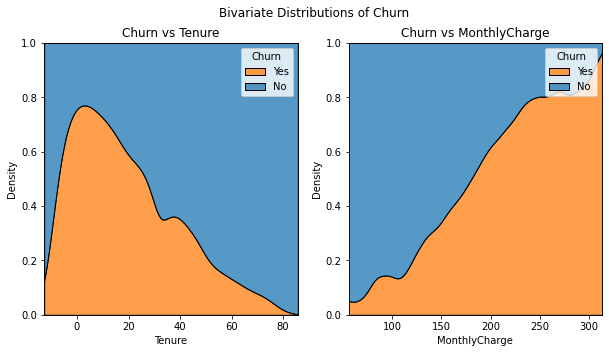

In [18]:
figure, axes = plt.subplots(1, 2, figsize=(10,5))
figure.suptitle('Bivariate Distributions of Churn')
axes[0].set_title('Churn vs Tenure')
axes[1].set_title('Churn vs MonthlyCharge')
sns.kdeplot(ax = axes[0], data = data, x = 'Tenure',hue = 'Churn',common_norm = False,multiple = 'fill')
sns.kdeplot(ax = axes[1], data = data, hue = 'Churn', x = 'MonthlyCharge',common_norm = False, multiple = 'fill')
axes[0].legend(labels = ['Yes','No'],title = 'Churn')
axes[1].legend(labels = ['Yes','No'],title = 'Churn')
plt.show()

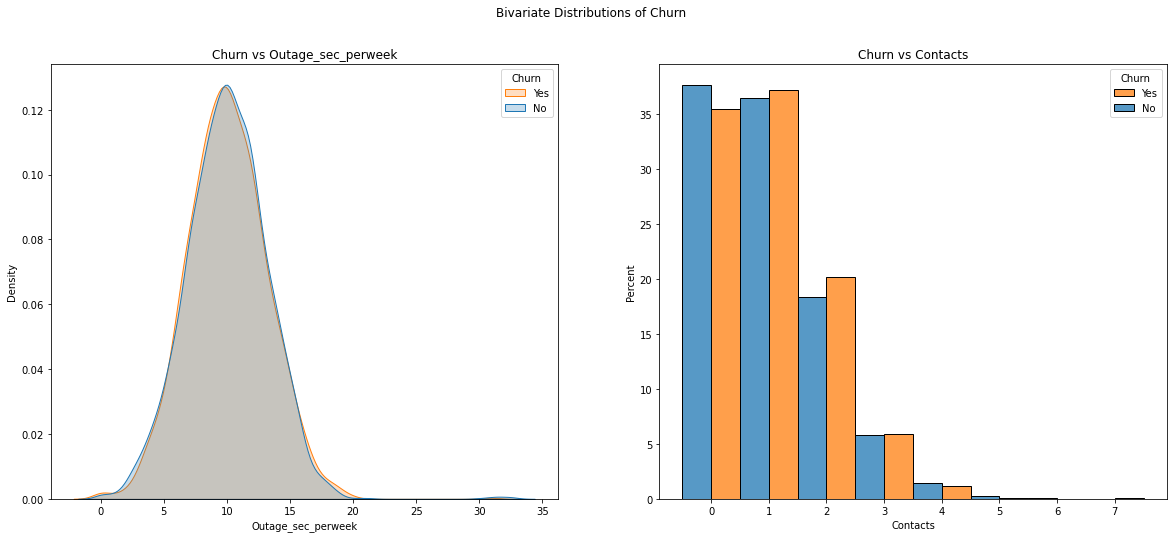

In [19]:
figure, axes = plt.subplots(1, 2, figsize=(20,8))
figure.suptitle('Bivariate Distributions of Churn')
axes[0].set_title('Churn vs Outage_sec_perweek')
axes[1].set_title('Churn vs Contacts')
sns.kdeplot(ax = axes[0], data = data, x = 'Outage_sec_perweek',fill = True,hue = 'Churn',multiple = 'layer',common_norm = False)
rcParams['figure.figsize'] = 15, 10
sns.histplot(ax = axes[1], data = data, hue = 'Churn', x = 'Contacts',stat = 'percent', multiple = 'dodge',common_norm = False, discrete = True)
axes[0].legend(labels = ['Yes','No'],title = 'Churn')
axes[1].legend(labels = ['Yes','No'],title = 'Churn')
plt.show()

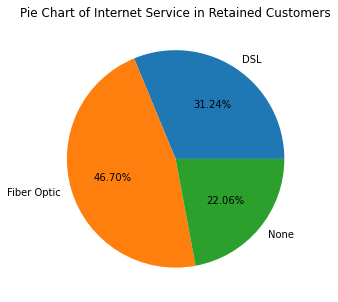

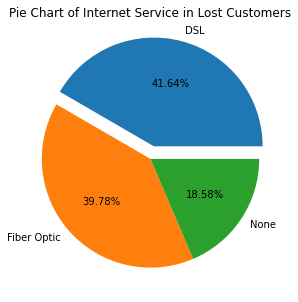

In [20]:
# Create Two Pie Charts One for Churn = 1 and one for Churn = 0 
# Pie charts will contain the proportions of internet services enrolled for 
# churned and non churned customers
temp_n = data[data['Churn'] == 0].copy(deep = True)
temp_y = data[data['Churn'] == 1].copy(deep = True)
cols = ['DSL','Fiber Optic','None']
temp_n_data = []
temp_y_data = []
temp_key = []
for i in cols:
    temp_n_data.append(temp_n[i].sum())
    temp_key.append(i)
    temp_y_data.append(temp_y[i].sum())
rcParams['figure.figsize'] = 5, 5
plt.pie(temp_n_data, labels=temp_key, autopct='%.2f%%')
plt.title('Pie Chart of Internet Service in Retained Customers')
plt.show()
plt.pie(temp_y_data, labels=temp_key, autopct='%.2f%%',explode = [.12,0,0])
plt.title('Pie Chart of Internet Service in Lost Customers')
plt.show()

Visual Showing Customer Contract Distributions for Retained and Churned Customers 

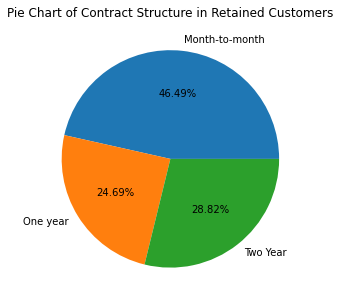

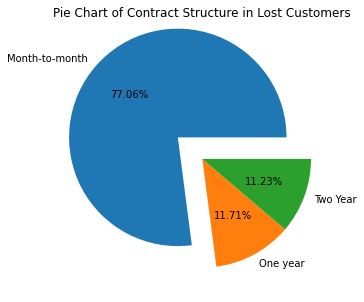

In [21]:
# Create Two Pie Charts One for Churn = 1 and one for Churn = 0 
# Pie charts will contain the proportions of internet services enrolled for 
# churned and non churned customers
temp_n = data[data['Churn'] == 0].copy(deep = True)
temp_y = data[data['Churn'] == 1].copy(deep = True)
cols = ['Month-to-month','One year','Two Year']
temp_n_data = []
temp_y_data = []
temp_key = []
for i in cols:
    temp_n_data.append(temp_n[i].sum())
    temp_key.append(i)
    temp_y_data.append(temp_y[i].sum())
rcParams['figure.figsize'] = 5, 5
plt.pie(temp_n_data, labels=temp_key, autopct='%.2f%%')
plt.title('Pie Chart of Contract Structure in Retained Customers')
plt.show()
plt.pie(temp_y_data, labels=temp_key, autopct='%.2f%%',explode = [.3,0,0])
plt.title('Pie Chart of Contract Structure in Lost Customers')
plt.show()

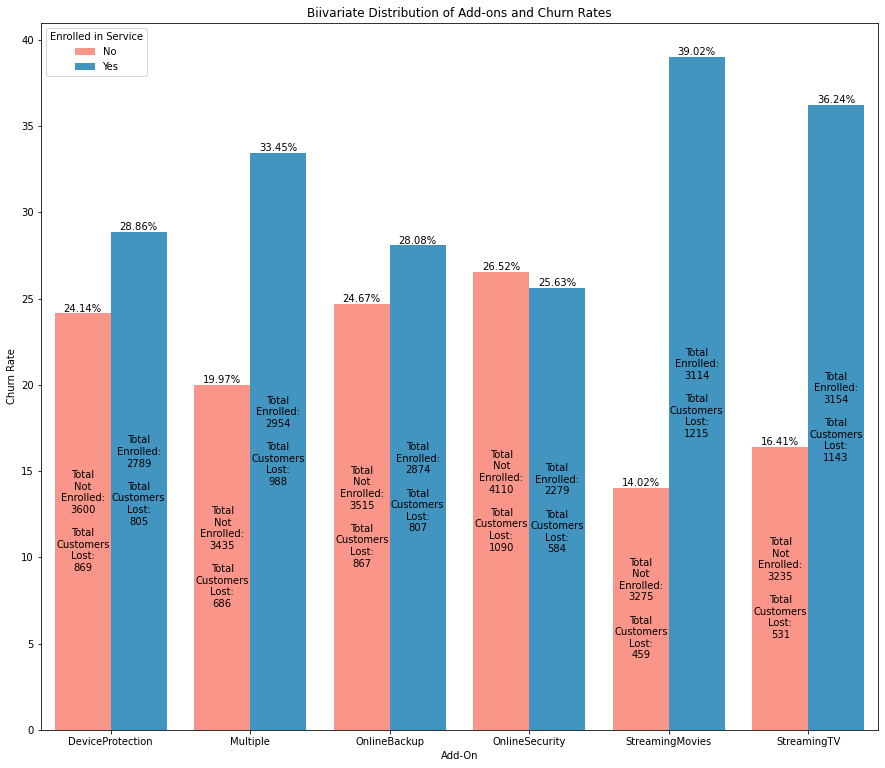

,Add-On,Enrolled,Churn Rate,Retention Rate,Count,Customers Lost
4,DeviceProtection,No,24.14,75.86,3600,869.0
5,DeviceProtection,Yes,28.86,71.14,2789,805.0
10,Multiple,No,19.97,80.03,3435,686.0
11,Multiple,Yes,33.45,66.55,2954,988.0
0,OnlineBackup,No,24.67,75.33,3515,867.0
1,OnlineBackup,Yes,28.08,71.92,2874,807.0
2,OnlineSecurity,No,26.52,73.48,4110,1090.0
3,OnlineSecurity,Yes,25.63,74.37,2279,584.0
6,StreamingMovies,No,14.02,85.98,3275,459.0
7,StreamingMovies,Yes,39.02,60.98,3114,1215.0


In [22]:
add = ['OnlineBackup','OnlineSecurity',
           'DeviceProtection','StreamingMovies',
           'StreamingTV','Multiple']
df = {
    'Add-On':[],
    'Enrolled':[],
    'Churn Rate':[],
    'Retention Rate':[],
    'Count':[]
}
fil_y = data[data['Churn'] == 1]
fil_n = data[data['Churn'] == 0]

for i in add:
    for opt in [0,1]:
        df['Add-On'].append(i)
        if opt == 1:
            df['Enrolled'].append('Yes')
        else:
            df['Enrolled'].append('No')
        # People  with service value i who did churn
        temp_y = fil_y[fil_y[i] == opt]
        # People with service value i who we retained
        temp_n = fil_n[fil_n[i]==opt]
        # Number of people with service value i
        total  = len(temp_y) + len(temp_n)
        #Churn Rate
        churn_rate = round(len(temp_y)/total *100,2)
        df['Churn Rate'].append(churn_rate)
        df['Retention Rate'].append(100-churn_rate)
        df['Count'].append(total)
df = pd.DataFrame(df).sort_values(by = ['Add-On','Enrolled'])
# Calculating how many people left for each add-on/enrolled
for lab,row in df.iterrows():
    df.loc[lab,'Customers Lost'] = round((df.loc[lab,'Churn Rate']/100) * (df.loc[lab,'Count']))
df['Customers Lost'].astype('Int64')
no = df[df['Enrolled'] == 'No'].index
yes = df[df['Enrolled'] == 'Yes'].index
no_str = []
yes_str = []
for i in no:
    no_str.append(f"Total\nNot\nEnrolled:\n{df.loc[i,'Count']}\n\nTotal\nCustomers\nLost:\n{int(df.loc[i,'Customers Lost'])}")
for i in yes:
    yes_str.append(f"Total\nEnrolled:\n{df.loc[i,'Count']}\n\nTotal\nCustomers\nLost:\n{int(df.loc[i,'Customers Lost'])}")
rcParams['figure.figsize'] = 15, 13
a =sns.barplot(data = df, x = 'Add-On', hue = 'Enrolled', y = 'Churn Rate',alpha = .83,color = (0.1, 0.5, 0.7),saturation = 1)
for i in a.patches[:6] : 
    i.set_facecolor('Salmon')
#Calculating number of people enrolled in service that churned

plt.legend(title = 'Enrolled in Service', loc = 'upper left')
a.bar_label(a.containers[0],fmt='%.2f%%')
a.bar_label(a.containers[0],no_str,label_type = 'center')
a.bar_label(a.containers[1],fmt='%.2f%%')
a.bar_label(a.containers[1],yes_str,label_type = 'center', fmt = '%Enrolled%')
plt.title('Biivariate Distribution of Add-ons and Churn Rates')
plt.show()
df

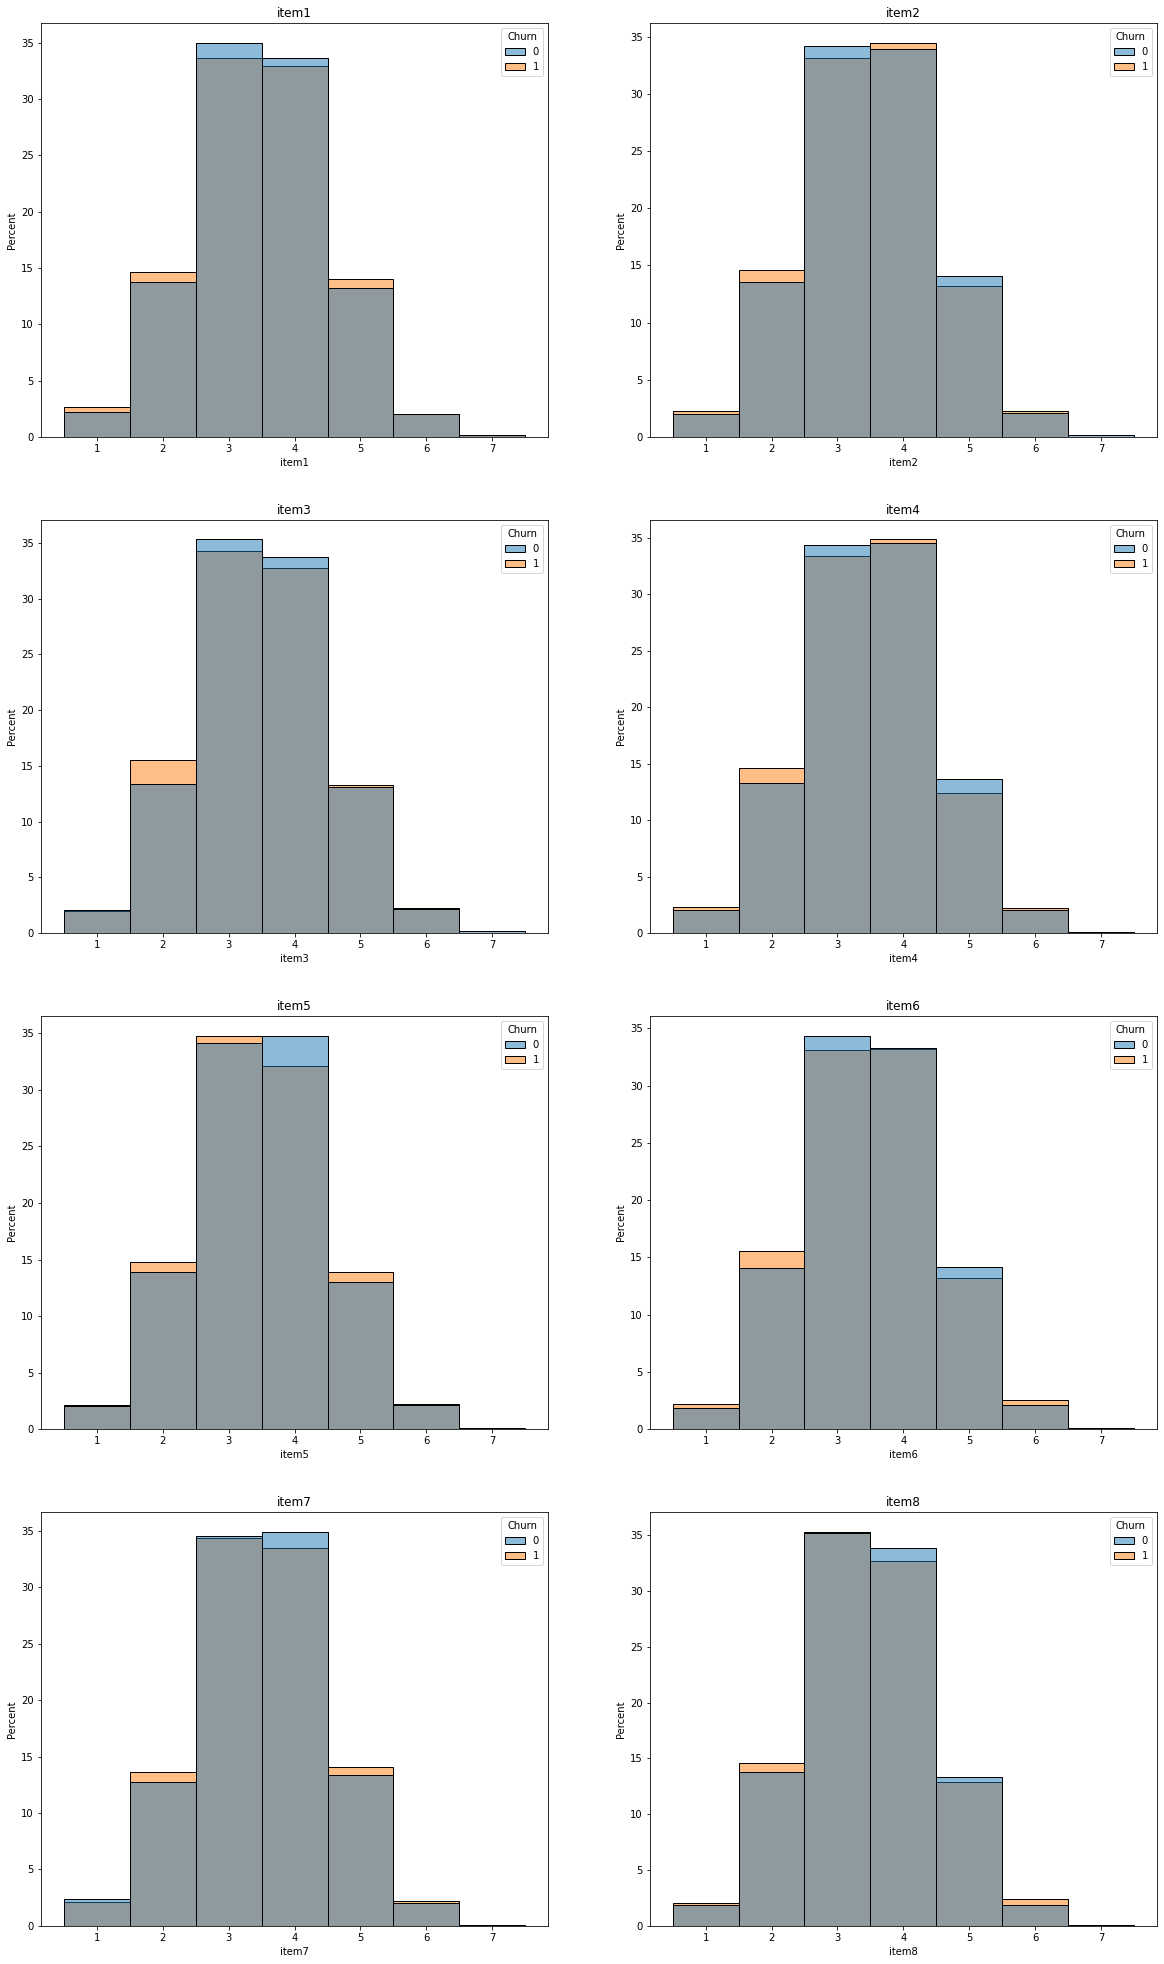

In [23]:
# Bivariate Distributions of Items 1-8
items = [x for x in stat.Column if 'item' in x]
figure, axes = plt.subplots(4, 2, figsize=(20,35))
ind1 = 0
ind2 = 0
for i in items:
    axes[ind1][ind2].set_title(f'{i}')
    x = sns.histplot(ax = axes[ind1][ind2], data = data, x = i,common_norm = False, 
                    discrete= True,stat = 'percent',hue = 'Churn')
    #x.bar_label(x.containers[0],labels = [f'{round(x,2)}' for x in x.containers[0].datavalues])
    #x.bar_label(x.containers[1],labels = [f'{round(x,2)}' for x in x.containers[1].datavalues])
    if ind2 == 0:
        ind2 = 1
    elif ind2 == 1:
        ind1 += 1
        ind2 = 0
plt.show()

In [24]:
#Set seed for reproducability
np.random.seed = 10000
dfs = [data[data['Churn'] == 0],data[data['Churn'] == 1]]
samples = []
#Iterate through filtered dfs sampling to get indexes from each df
for i in dfs:
    inds = np.random.choice(i.index,size = 1500, replace = True)
    samples.append(inds)

sample = list(samples[0])
sample.extend(list(samples[1]))
np.random.shuffle(sample)
sample = data.loc[sample,:].copy(deep = True).reset_index(drop = True)

# Building list for iteration through item columns
items = [x for x in data.columns if 'item' in x]
for lab,row in sample.iterrows():
    sample.loc[lab,'Survey'] = sample.loc[lab,[x for x in sample.columns if 'item' in x]].mean()
    sample.loc[lab,'Streaming'] = (sample.loc[lab,'StreamingMovies'] + sample.loc[lab,'StreamingTV'])
items.extend(['StreamingMovies','StreamingTV'])
sample = sample.drop(columns = items,axis = 1)
sample = sample.rename(columns = {'Fiber Optic': 'FiberOptic','Month-to-month': 'monthly','Two Year': 'Biannual','One year':'Annual'})
sample['Churn'].map({1:'Yes',0:'No'})
sample.to_csv('D:\\DataProjects\\WGU\\Predictive Modeling\\Logistic Regression\\sample.csv')

In [25]:
sample

,Income,Churn,Outage_sec_perweek,Contacts,Multiple,OnlineSecurity,OnlineBackup,DeviceProtection,Tenure,MonthlyCharge,FiberOptic,Annual,monthly,Biannual,DSL,None,Survey,Streaming
0,4308.47,1,5.735011,1,0,0,0,0,2.337769,208.144200,1.0,0.0,1.0,0.0,0.0,0.0,3.000,2.0
1,64027.82,1,9.681618,1,1,0,0,0,6.446079,170.914436,1.0,0.0,1.0,0.0,0.0,0.0,3.750,1.0
2,47618.81,0,11.941623,1,0,1,1,0,4.106981,129.262425,0.0,0.0,0.0,1.0,1.0,0.0,4.500,0.0
3,104548.67,1,8.721613,0,0,0,0,1,4.836004,117.516562,0.0,0.0,1.0,0.0,1.0,0.0,4.500,0.0
4,35172.82,1,9.065979,0,1,1,1,1,51.830820,244.826300,0.0,0.0,1.0,0.0,0.0,1.0,3.375,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,69697.68,0,7.634852,1,1,1,1,1,57.781330,163.640000,0.0,0.0,1.0,0.0,1.0,0.0,3.125,0.0
2996,20164.01,0,8.799714,0,1,1,0,0,55.449910,194.896000,1.0,0.0,1.0,0.0,0.0,0.0,3.500,1.0
2997,23177.92,1,10.674320,0,0,1,0,1,71.200510,233.966700,1.0,0.0,1.0,0.0,0.0,0.0,3.250,2.0
2998,57982.69,1,5.836127,2,1,1,0,1,3.593530,253.384100,1.0,1.0,0.0,0.0,0.0,0.0,2.875,2.0


# <font color='green'> Regression Modeling</font>

In [26]:
response = 'Churn'
#Columns to use for initial logistic regression
cols_keep =  ['Multiple', 'Tenure','Income',
              'MonthlyCharge', 'Survey','monthly', 'DSL',
              'Streaming','DeviceProtection', 'Outage_sec_perweek','Contacts',
              'OnlineBackup', 'OnlineSecurity']

explanatory = cols_keep
expression = 'Churn ~ '
#Creating expression with all explanatory variables
for var in explanatory:
    ind = explanatory.index(var)
    if ind == 0:
        expression += f'{var}'
    else:
        expression += f' + {var}'

# Creating the initial Multiple Regression model
mdl = logit(expression, data = sample).fit()
print('Expression:')
print(expression)
conf_matrix = mdl.pred_table()
TN = conf_matrix[0,0]
TP = conf_matrix[1,1]
FN = conf_matrix[1,0]
FP = conf_matrix[0,1]
# Calculate and print the accuracy
accuracy = (TN + TP) / (TN + FN + FP + TP)
print("accuracy: ", accuracy)

# Calculate and print the sensitivity
sensitivity = TP / (TP + FN)
print("sensitivity: ", sensitivity)

# Calculate and print the specificity
specificity = TN / (TN + FP)
print("specificity: ", specificity)

Optimization terminated successfully.
         Current function value: 0.252638
         Iterations 8
Expression:
Churn ~ Multiple + Tenure + Income + MonthlyCharge + Survey + monthly + DSL + Streaming + DeviceProtection + Outage_sec_perweek + Contacts + OnlineBackup + OnlineSecurity
accuracy:  0.8896666666666667
sensitivity:  0.9093333333333333
specificity:  0.87


In [27]:
mdl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2986
Method:                           MLE   Df Model:                           13
Date:                Wed, 15 Nov 2023   Pseudo R-squ.:                  0.6355
Time:                        08:00:33   Log-Likelihood:                -757.91
converged:                       True   LL-Null:                       -2079.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -6.4039      0.694     -9.233      0.000      -7.763      -5.044
Multiple               1.3257      0.190      6.971      0.000       0.953       1.698
Tenure                -0.1140      0.005    -23.852      0.000      -0.123      -0.105
Income             -4.736e-06   2.65e-06     -1.786      0.074   -9.93e-06    4.62e-07
MonthlyCharge          0.0159      0.004      3.915      0.000       0.008       0.024
Survey                -0.0902      0.123     -0.733      0.464      -0.331       0.151
monthly                3.3788      0.174     19.392      0.000       3.037       3.720
DSL                    1.4427      0.151      9.568      0.000       1.147       1.738
Streaming              2.4554      0.235     10.459      0.000       1.995       2.916
DeviceProtection       0.4369      0.143      3.052      0.002       0.156       0.718
Outage_sec_perweek     0.0103      0.021      0.498      0.618      -0.030       0.051
Contacts               0.0377      0.065      0.577      0.564      -0.090       0.166
OnlineBackup           0.3825      0.161      2.376      0.018       0.067       0.698
OnlineSecurity         0.1450      0.137      1.056      0.291      -0.124       0.414
======================================================================================
"""

# <font color='green'> Regression Modeling Reduction using Forward Selection </font>

In [51]:
#Forward Selection Process 
# adding most accurate feature at each iteration
# VIF values are assessed in the cell below and we only select
# The most accurate feature that keeps our VIF values below 10
temp = 'Churn ~ Tenure + MonthlyCharge + monthly + FiberOptic +'
cols_keep =  ['FiberOptic', 'Annual','Multiple', 'Tenure','Income',
              'MonthlyCharge', 'Survey','monthly', 'DSL',
              'Streaming','DeviceProtection', 'Outage_sec_perweek','Contacts',
              'OnlineBackup', 'OnlineSecurity']
models = {
    'Expression' : [],
    'Accuracy' : [],
    'Sensitivity' : [],
    'Specificity' : [],
    'Added Var' : []
}

for i in cols_keep:
    if i not in temp:
        expression = temp + i
        # Creating the initial Multiple Regression model
        mdl = logit(expression, data = sample).fit()
        # Performance Statistics
        conf_matrix = mdl.pred_table()
        TN = conf_matrix[0,0]
        TP = conf_matrix[1,1]
        FN = conf_matrix[1,0]
        FP = conf_matrix[0,1]
        
        # Calculate the accuracy
        accuracy = (TN + TP) / (TN + FN + FP + TP)
        # Calculate the sensitivity
        sensitivity = TP / (TP + FN)
        # Calculate the specificity
        specificity = TN / (TN + FP)
        
        #Apply to dataframe constructor
        models['Expression'].append(expression)
        models['Accuracy'].append(accuracy)
        models['Sensitivity'].append(sensitivity)
        models['Specificity'].append(specificity)
        models['Added Var'].append(i)
#Create dataframe of all models
M = pd.DataFrame(models).sort_values(by = ['Accuracy'], ascending = False)
M

Optimization terminated successfully.
         Current function value: 0.262304
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.262586
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.262433
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.262191
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.261376
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.257667
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.262536
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.262602
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.262503
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.258201
  

,Expression,Accuracy,Sensitivity,Specificity,Added Var
5,Churn ~ Tenure + MonthlyCharge + monthly + Fib...,0.888000,0.903333,0.872667,Streaming
4,Churn ~ Tenure + MonthlyCharge + monthly + Fib...,0.886000,0.901333,0.870667,DSL
9,Churn ~ Tenure + MonthlyCharge + monthly + Fib...,0.885000,0.903333,0.866667,OnlineBackup
2,Churn ~ Tenure + MonthlyCharge + monthly + Fib...,0.884000,0.899333,0.868667,Income
3,Churn ~ Tenure + MonthlyCharge + monthly + Fib...,0.883000,0.898000,0.868000,Survey
0,Churn ~ Tenure + MonthlyCharge + monthly + Fib...,0.882333,0.899333,0.865333,Annual
6,Churn ~ Tenure + MonthlyCharge + monthly + Fib...,0.882333,0.899333,0.865333,DeviceProtection
8,Churn ~ Tenure + MonthlyCharge + monthly + Fib...,0.882000,0.899333,0.864667,Contacts
1,Churn ~ Tenure + MonthlyCharge + monthly + Fib...,0.881667,0.898000,0.865333,Multiple
10,Churn ~ Tenure + MonthlyCharge + monthly + Fib...,0.881667,0.898000,0.865333,OnlineSecurity


# <font color='green'> VIF assessment</font>
### <font color='green'> We use this in between steps in Forward Selection to ensure we aren't including columns that have multicollinearity, even when it is the most accurate feature to add to the model </font>

In [29]:
#Assessing VIF of reduced model
cols =  ['Tenure', 'MonthlyCharge','monthly','FiberOptic']
vif = sample[cols].copy().dropna()
X = vif[cols]
vif_data = pd.DataFrame()
vif_data['Features'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values,i) for i in range(len(X.columns))]
#Printing the features of the regression model and the VIF values
print(vif_data)

        Features       VIF
0         Tenure  2.007328
1  MonthlyCharge  4.318636
2        monthly  2.371670
3     FiberOptic  1.857919


# <font color='green'> Reduced Model Forward Selection </font>

In [52]:
explanatory = ['Tenure', 'MonthlyCharge','monthly','FiberOptic']
expression = 'Churn ~ '
for i in explanatory:
    if explanatory.index(i) == 0:
        expression = expression + i
    else:
        expression = f'{expression} + {i}'
    # Making the model with the expression    
    reduced = logit(expression, data = sample).fit()
    # Performance Statistics
    print('Expression:')
    print(expression)
    conf_matrix = reduced.pred_table()
    TN = conf_matrix[0,0]
    TP = conf_matrix[1,1]
    FN = conf_matrix[1,0]
    FP = conf_matrix[0,1]
    # Calculate and print the accuracy
    accuracy = (TN + TP) / (TN + FN + FP + TP)
    print("accuracy: ", accuracy)

    # Calculate and print the sensitivity
    sensitivity = TP / (TP + FN)
    print("sensitivity: ", sensitivity)

    # Calculate and print the specificity
    specificity = TN / (TN + FP)
    print("specificity: ", specificity)


Optimization terminated successfully.
         Current function value: 0.516329
         Iterations 6
Expression:
Churn ~ Tenure
accuracy:  0.7646666666666667
sensitivity:  0.8846666666666667
specificity:  0.6446666666666667
Optimization terminated successfully.
         Current function value: 0.388028
         Iterations 7
Expression:
Churn ~ Tenure + MonthlyCharge
accuracy:  0.8133333333333334
sensitivity:  0.8373333333333334
specificity:  0.7893333333333333
Optimization terminated successfully.
         Current function value: 0.299587
         Iterations 8
Expression:
Churn ~ Tenure + MonthlyCharge + monthly
accuracy:  0.8653333333333333
sensitivity:  0.8906666666666667
specificity:  0.84
Optimization terminated successfully.
         Current function value: 0.262606
         Iterations 8
Expression:
Churn ~ Tenure + MonthlyCharge + monthly + FiberOptic
accuracy:  0.8813333333333333
sensitivity:  0.8973333333333333
specificity:  0.8653333333333333


In [31]:
reduced.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2995
Method:                           MLE   Df Model:                            4
Date:                Wed, 15 Nov 2023   Pseudo R-squ.:                  0.6211
Time:                        08:00:34   Log-Likelihood:                -787.82
converged:                       True   LL-Null:                       -2079.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -9.1387      0.434    -21.033      0.000      -9.990      -8.287
Tenure           -0.1139      0.005    -23.732      0.000      -0.123      -0.104
MonthlyCharge     0.0587      0.003     22.599      0.000       0.054       0.064
monthly           3.3035      0.168     19.646      0.000       2.974       3.633
FiberOptic       -2.0992      0.156    -13.470      0.000      -2.405      -1.794
=================================================================================
"""

# <font color='green'> Comparing Initial and Reduced Model</font>

In [32]:
#Reduced Model
expression = 'Churn ~ Tenure + MonthlyCharge + monthly + FiberOptic'
reduced = logit(expression, data = sample).fit()
# Performance Statistics
print('Expression:')
print(expression)
conf_matrix = reduced.pred_table()
TN = conf_matrix[0,0]
TP = conf_matrix[1,1]
FN = conf_matrix[1,0]
FP = conf_matrix[0,1]
# Calculate and print the accuracy
accuracy = (TN + TP) / (TN + FN + FP + TP)
print("accuracy: ", accuracy)

# Calculate and print the sensitivity
sensitivity = TP / (TP + FN)
print("sensitivity: ", sensitivity)

# Calculate and print the specificity
specificity = TN / (TN + FP)
print("specificity: ", specificity)

Optimization terminated successfully.
         Current function value: 0.262606
         Iterations 8
Expression:
Churn ~ Tenure + MonthlyCharge + monthly + FiberOptic
accuracy:  0.8813333333333333
sensitivity:  0.8973333333333333
specificity:  0.8653333333333333


In [33]:
#Initial Model Accuracy Metrics
conf_matrix = mdl.pred_table()
TN = conf_matrix[0,0]
TP = conf_matrix[1,1]
FN = conf_matrix[1,0]
FP = conf_matrix[0,1]
# Calculate and print the accuracy
accuracy = (TN + TP) / (TN + FN + FP + TP)
print("accuracy: ", accuracy)

# Calculate and print the sensitivity
sensitivity = TP / (TP + FN)
print("sensitivity: ", sensitivity)

# Calculate and print the specificity
specificity = TN / (TN + FP)
print("specificity: ", specificity)

accuracy:  0.8816666666666667
sensitivity:  0.898
specificity:  0.8653333333333333


[[1298.  202.]
 [ 153. 1347.]]


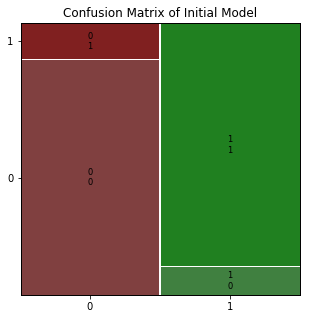

[[1298.  202.]
 [ 154. 1346.]]


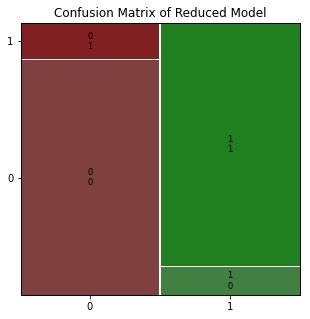

Difference from Initial Model:
[[ 0.  0.]
 [-1.  1.]]


In [34]:
rcParams['figure.figsize'] = 5, 5
mosaic(mdl.pred_table())
plt.title('Confusion Matrix of Initial Model')
print(mdl.pred_table())
plt.show()
mosaic(reduced.pred_table())
plt.title('Confusion Matrix of Reduced Model')
print(reduced.pred_table())
plt.show()
print(f'Difference from Initial Model:\n{mdl.pred_table() - reduced.pred_table()}')

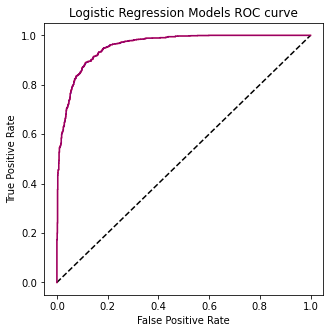

In [47]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
fpr, tpr, thresholds = roc_curve(sample.Churn,mdl.predict(sample))
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr,label = 'Logistic Regression',color = 'red')
fpr, tpr, thresholds = roc_curve(sample.Churn,reduced.predict(sample))
plt.plot(fpr,tpr,label = 'Logistic Regression',color = 'blue',alpha = .4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression Models ROC curve')
plt.show()

In [48]:
print(f'ROC AUC Score Initial Model:{roc_auc_score(sample.Churn,mdl.predict(sample))}')
print(f'ROC AUC Score Reduced Model:{roc_auc_score(sample.Churn,reduced.predict(sample))}')

ROC AUC Score Initial Model:0.9570497777777778
ROC AUC Score Reduced Model:0.957048888888889


Interpreting Odds Ratios of Reduced Model
for Binary Variables

In [106]:
coef = reduced.params
coef = coef[3:]
for i in range(len(coef)):
    print(f'{np.exp(coef[i])} times more likely to churn when {coef.keys()[i]} is present')
print(f'{np.exp(coef[0]+coef[1])} times more likely to churn when both monthly and FiberOptic are present')

20.430638755821807 times more likely to churn when monthly is present
0.0962160068801513 times more likely to churn when FiberOptic is present
1.9657544790960366 times more likely to churn when both monthly and FiberOptic are present
